In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training data
df = pd.read_csv('train.csv')

# Show the first 5 rows
display(df.head())

# List all the columns
print(df.columns.tolist())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [13]:
# Get the correlations of all numerical features with SalePrice
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
top_correlations = corr_matrix['SalePrice'].sort_values(ascending=False)

# Display the top 10 most influential features
print("Top 10 Features most correlated with SalePrice:")
print(top_correlations.head(12))

Top 10 Features most correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


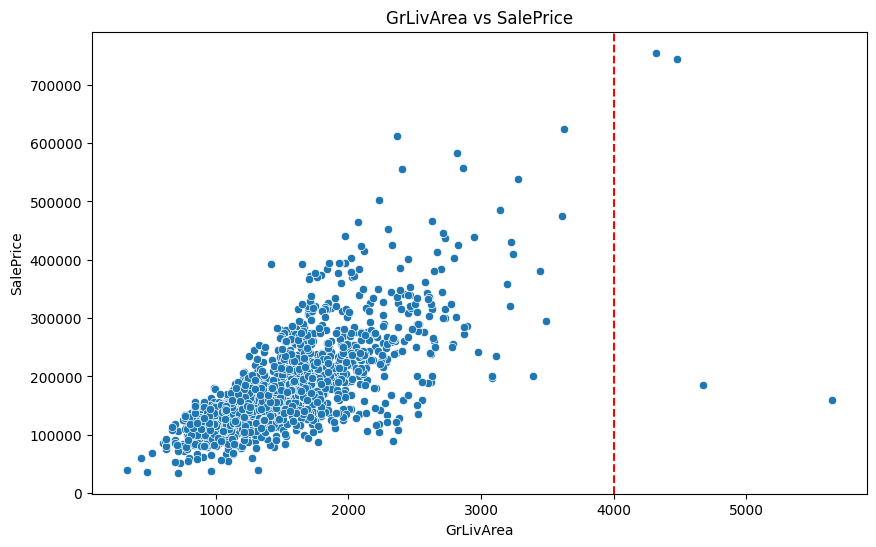

In [14]:
# Check and remove outliers per Dean De Cock's suggestion
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.axvline(x=4000, color='r', linestyle='--')
plt.show()

In [15]:
# Remove outliers
df_no_outliers = df[df['GrLivArea'] < 4000].copy()

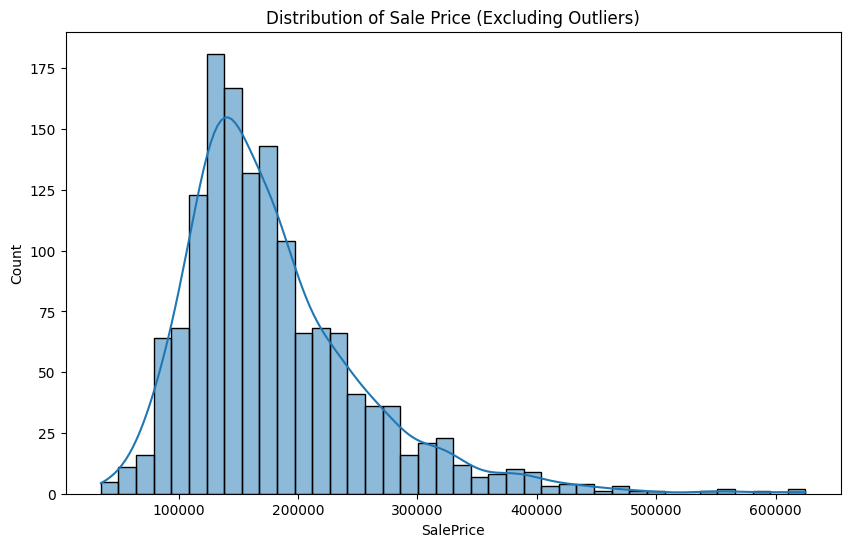

In [16]:
# Graph sale price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_no_outliers['SalePrice'], kde=True)
plt.title('Distribution of Sale Price (Excluding Outliers)')
plt.show()

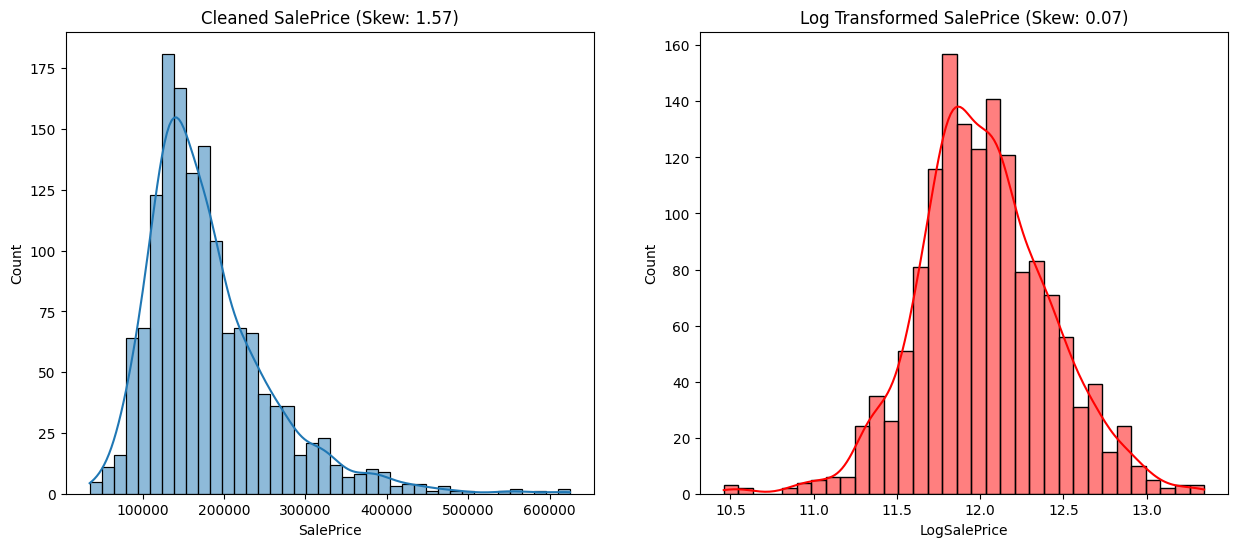

In [17]:
import numpy as np

# Create a figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Original Skewed Data
sns.histplot(df_no_outliers['SalePrice'], kde=True, ax=ax1)
ax1.set_title(f"Cleaned SalePrice (Skew: {df_no_outliers['SalePrice'].skew():.2f})")

# Plot 2: Log Transformed Data
df_no_outliers['LogSalePrice'] = np.log1p(df_no_outliers['SalePrice'])
sns.histplot(df_no_outliers['LogSalePrice'], kde=True, ax=ax2, color='red')
ax2.set_title(f"Log Transformed SalePrice (Skew: {df_no_outliers['LogSalePrice'].skew():.2f})")

plt.show()

In [18]:
df_no_outliers.to_csv('train_clean.csv', index=False)

print("Saved cleaned data to train_clean.csv.")

Saved cleaned data to train_clean.csv.


In [19]:
# Check for missing values and sort by highest percentage
missing_data = df_no_outliers.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_data / len(df_no_outliers)) * 100

# Combine into a table
missing_df = pd.concat([missing_data, missing_percentage], axis=1, keys=['Total', 'Percent'])
print(missing_df[missing_df['Total'] > 0])

              Total    Percent
PoolQC         1451  99.656593
MiscFeature    1402  96.291209
Alley          1365  93.750000
Fence          1176  80.769231
MasVnrType      871  59.821429
FireplaceQu     690  47.390110
LotFrontage     259  17.788462
GarageType       81   5.563187
GarageYrBlt      81   5.563187
GarageCond       81   5.563187
GarageFinish     81   5.563187
GarageQual       81   5.563187
BsmtFinType2     38   2.609890
BsmtExposure     38   2.609890
BsmtQual         37   2.541209
BsmtCond         37   2.541209
BsmtFinType1     37   2.541209
MasVnrArea        8   0.549451
Electrical        1   0.068681


In [25]:
# Handle categorical missing values by setting to 'None'
cols_to_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
    'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
    'BsmtFinType1', 'BsmtFinType2'
]
for col in cols_to_none:
    df_no_outliers[col] = df_no_outliers[col].fillna('None')

# Handle MasVnrArea missing values by setting to 0
df_no_outliers['MasVnrArea'] = df_no_outliers['MasVnrArea'].fillna(0)

# Handle LotFrontage missing values by using neighborhood median
df_no_outliers["LotFrontage"] = df_no_outliers.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Handle Electrical missing values by using overall mode
df_no_outliers['Electrical'] = df_no_outliers['Electrical'].fillna(df_no_outliers['Electrical'].mode()[0])

# Handle GarageYrBlt missing values by using YearBuilt
df_no_outliers['GarageYrBlt'] = df_no_outliers['GarageYrBlt'].fillna(df_no_outliers['YearBuilt'])

print(f"Remaining missing values: {df_no_outliers.isnull().sum().sum()}")

Remaining missing values: 0


In [28]:
# Convert categorical variables using one-hot encoding
df_final = pd.get_dummies(df_no_outliers)

# Save as train_clean.csv
df_final.to_csv('train_clean.csv', index=False)

print(f"Final shape after encoding: {df_final.shape}")
print("Cleaned data has been saved to artifacts/train_clean.csv. You are now ready to run mlflow.example.ipynb.")

Final shape after encoding: (1456, 304)
Data saved to train_clean.csv.
